In [1]:
import glob, os
import numpy as np
from scipy import ndimage
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
in_dir = '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/20181204_gefs_en18/500m/celltracking/20181204.1200_20181205.0000/'
# filename = f'{in_dir}celltracks_20181204_1500.nc'
filename = f'{in_dir}celltracks_20181204_2230.nc'

In [3]:
ds = xr.open_dataset(filename, mask_and_scale=False)
ny, nx = ds.sizes['lat'], ds.sizes['lon']
tracknumber = ds.tracknumber

In [4]:
tracknumber

<xarray.DataArray 'tracknumber' (time: 1, lat: 865, lon: 750)>
[648750 values with dtype=int32]
Coordinates:
  * time     (time) datetime64[ns] 2018-12-04T22:30:00
  * lat      (lat) int64 0 1 2 3 4 5 6 7 8 ... 857 858 859 860 861 862 863 864
  * lon      (lon) int64 0 1 2 3 4 5 6 7 8 ... 742 743 744 745 746 747 748 749
Attributes:
    _FillValue:  0
    long_name:   Track number in this file at a given pixel
    units:       unitless

In [5]:
# Create a coordinate to mimic subsampling a 5:1 ratio of the full coordinate
ratio = 5
xcoord = (np.linspace(2, nx*ratio+2, nx, endpoint=False, dtype=int))
ycoord = (np.linspace(2, ny*ratio+2, ny, endpoint=False, dtype=int))
print(xcoord[0:10], xcoord[-10:])
print(ycoord[0:10], ycoord[-10:])

[ 2  7 12 17 22 27 32 37 42 47] [3702 3707 3712 3717 3722 3727 3732 3737 3742 3747]
[ 2  7 12 17 22 27 32 37 42 47] [4277 4282 4287 4292 4297 4302 4307 4312 4317 4322]


In [6]:
# Create a full coordinate
xcoord_out = np.arange(0, nx*ratio, 1)
ycoord_out = np.arange(0, ny*ratio, 1)
xcoord_out, ycoord_out

(array([   0,    1,    2, ..., 3747, 3748, 3749]),
 array([   0,    1,    2, ..., 4322, 4323, 4324]))

In [7]:
# Replace the coordinate of the variable
tracknumber = tracknumber.assign_coords({'lat':ycoord, 'lon':xcoord})
tracknumber

<xarray.DataArray 'tracknumber' (time: 1, lat: 865, lon: 750)>
[648750 values with dtype=int32]
Coordinates:
  * time     (time) datetime64[ns] 2018-12-04T22:30:00
  * lat      (lat) int64 2 7 12 17 22 27 32 ... 4297 4302 4307 4312 4317 4322
  * lon      (lon) int64 2 7 12 17 22 27 32 ... 3722 3727 3732 3737 3742 3747
Attributes:
    _FillValue:  0
    long_name:   Track number in this file at a given pixel
    units:       unitless

In [8]:
# Remap to the full coordinate
tracknumber_out = tracknumber.interp(lon=xcoord_out, lat=ycoord_out, method='nearest', assume_sorted=True, kwargs={"fill_value": "extrapolate"},)

In [9]:
tracknumber_out.shape

(1, 4325, 3750)

In [10]:
tracknumber_out.squeeze().data[0:10,0:10]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

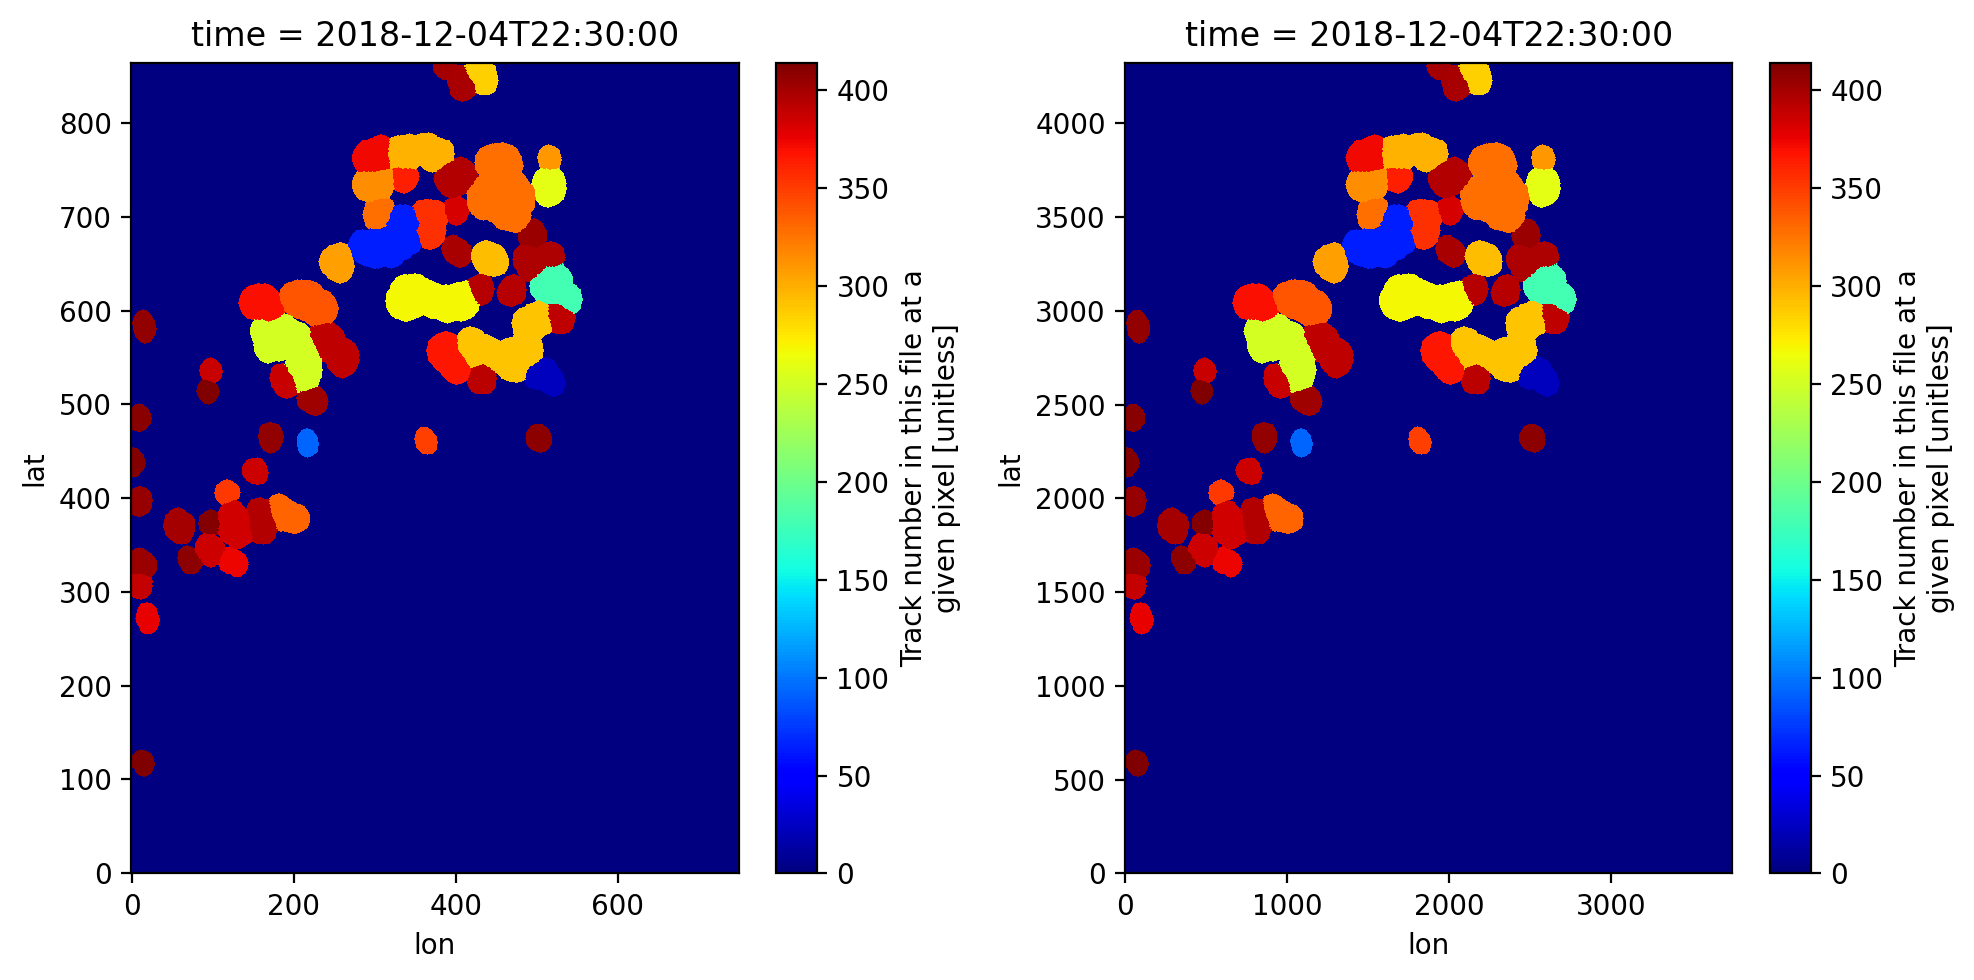

In [15]:
fig, axes = plt.subplots(1, 2, figsize=[10,5], dpi=200)
# ax = axes[0]
ds.tracknumber.plot(cmap='jet', ax=axes[0])
tracknumber_out.plot(cmap='jet', ax=axes[1])
fig.tight_layout()